# Notebook 4 — Análisis de Mundo Pequeño

**Prerequisito:** haber ejecutado el Notebook 02. Los archivos `outputs/fc_matrices/{MRI_ID}_fc_z.npy` deben existir.

**Alcance:** análisis a **un solo umbral** (Fisher-z = 0.20), alineado con el notebook 02. No incluye curvas multi-umbral ni AUC.

## Objetivo
Determinar si las redes cerebrales funcionales tienen organización de **mundo pequeño** (*small-world*) al umbral fijo de Fisher-z = 0.20, comparando sus propiedades topológicas contra dos modelos nulos:

- **Erdős-Rényi (ER):** grafo aleatorio con misma N y misma densidad de aristas.
- **Watts-Strogatz / Rewiring (WS):** rewiring aleatorio que preserva la distribución de grados de cada nodo (estándar en neuroimagen).

## Métricas
| Símbolo | Nombre | Interpretación |
|---|---|---|
| C | Coeficiente de clustering | Fracción de triángulos cerrados por nodo |
| L | Longitud de camino característica | Camino más corto promedio entre todos los pares de nodos |
| E_local | Eficiencia local | Conectividad del vecindario de cada nodo |
| E_global | Eficiencia global | Integración de información a nivel de red |
| σ (sigma) | Índice de mundo pequeño | σ = (C/C_rand) / (L/L_rand); σ > 1 → mundo pequeño |
| ω (omega) | Índice omega (Telesford 2011) | ω ∈ [-1,1]; ≈0 → mundo pequeño; →-1 lattice; →1 random |

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import bct
import warnings
from pathlib import Path
from scipy import stats
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

Path('outputs/sw_metrics').mkdir(exist_ok=True)
Path('figs').mkdir(exist_ok=True)

THRESHOLD = 0.20   # umbral fijo — mismo que notebook 02
N_NULL    = 100    # repeticiones por modelo nulo
N_REWIRE  = 10     # iteraciones de rewiring por arista (WS)
SEED      = 42
QUICK_MODE = True  # True → 20 sujetos/diagnóstico (~1 h); False → cohorte completa
rng       = np.random.default_rng(SEED)

print('Umbral fijo:', THRESHOLD)
print('Modo rápido:', QUICK_MODE)

Umbral fijo: 0.2
Modo rápido: True


## 1. Cargar matrices FC y metadatos

In [9]:
FC_DIR  = Path('outputs/fc_matrices')
eligible = pd.read_csv('outputs/eligible_fc_subjects.csv')

# Cargar solo sujetos que tienen archivo .npy
records = []
for _, row in eligible.iterrows():
    p = FC_DIR / f"{row['MRI_ID']}_fc_z.npy"
    if p.exists():
        records.append({'MRI_ID': row['MRI_ID'], 'diagnosis': row['diagnosis'],
                        'Age': row['Age'], 'site': row['site'], 'path': p})

meta = pd.DataFrame(records)
print(f'Sujetos con FC disponible: {len(meta)} / {len(eligible)} en eligible_fc_subjects.csv')
if len(meta) == 0:
    raise FileNotFoundError(
        'No hay archivos .npy en outputs/fc_matrices/. Ejecutá el Notebook 02 primero.'
    )
print(meta['diagnosis'].value_counts())

Sujetos con FC disponible: 1327 / 1327 en eligible_fc_subjects.csv
diagnosis
CN     555
AD     468
FTD    304
Name: count, dtype: int64


## 2. Funciones de umbralización y métricas de red

In [10]:
def threshold_fixed(fc_z: np.ndarray, thr: float) -> np.ndarray:
    """Binariza la matriz FC-z conservando conexiones >= thr (solo positivas)."""
    mat = fc_z.copy()
    np.fill_diagonal(mat, 0)
    B = (mat >= thr).astype(float)
    B = np.maximum(B, B.T)
    return B


def graph_metrics(B: np.ndarray) -> dict:
    """
    Calcula C, L, E_local, E_global para una matriz binaria (BCT).
    L vía charpath; requiere grafo conexo (verificar antes con NetworkX).
    """
    n = B.shape[0]

    C       = float(np.mean(bct.clustering_coef_bu(B)))
    E_local = float(np.mean(bct.efficiency_bin(B, local=True)))
    E_glob  = float(bct.efficiency_bin(B, local=False))

    # Longitud de camino característica vía BCT (más rápido que NetworkX)
    D = bct.distance_bin(B)
    # charpath devuelve (lambda, efficiency, ecc, radius, diameter)
    result = bct.charpath(D, include_diagonal=False, include_infinite=False)
    L = float(result[0])  # lambda = longitud de camino

    return {'C': C, 'L': L, 'E_local': E_local, 'E_global': E_glob}


def edge_density(B: np.ndarray) -> float:
    n = B.shape[0]
    return float(B.sum()) / (n * (n - 1))

## 3. Funciones de modelos nulos

### Erdős-Rényi
Genera grafos aleatorios con misma N y misma densidad p. No preserva la distribución de grados.

### Watts-Strogatz (rewiring preservando grados)
Parte de la matriz cerebral y hace rewiring aleatorio iterativo (BCT `randmio_und`), 
preservando el grado de cada nodo. Es el modelo nulo estándar en neuroimagen.

In [11]:
def null_erdos_renyi(n: int, p: float, n_null: int, seed: int) -> dict:
    """
    Genera n_null grafos ER con N nodos y densidad p.
    Devuelve promedios de C, L, E_local, E_global.
    """
    Cs, Ls, Els, Egs = [], [], [], []
    rng_local = np.random.default_rng(seed)

    for _ in range(n_null):
        G   = nx.erdos_renyi_graph(n, p, seed=int(rng_local.integers(1e6)))
        B_r = nx.to_numpy_array(G, dtype=float)
        np.fill_diagonal(B_r, 0)

        if nx.is_connected(G):
            m = graph_metrics(B_r)
            Cs.append(m['C']); Ls.append(m['L'])
            Els.append(m['E_local']); Egs.append(m['E_global'])

    return {
        'C_rand':       np.nanmean(Cs),
        'L_rand':       np.nanmean(Ls),
        'E_local_rand': np.nanmean(Els),
        'E_global_rand':np.nanmean(Egs),
    }


def null_ws_rewiring(B: np.ndarray, n_null: int, n_rewire: int) -> dict:
    """
    Genera n_null grafos aleatorios con rewiring que preserva la distribución de grados.
    Usa bct.randmio_und (equivalente al algoritmo de Maslov-Sneppen).
    """
    Cs, Ls, Els, Egs = [], [], [], []

    for _ in range(n_null):
        B_r, _ = bct.randmio_und(B, n_rewire)
        B_r    = (B_r > 0).astype(float)
        np.fill_diagonal(B_r, 0)

        G = nx.from_numpy_array(B_r)
        if nx.is_connected(G):
            m = graph_metrics(B_r)
            Cs.append(m['C']); Ls.append(m['L'])
            Els.append(m['E_local']); Egs.append(m['E_global'])

    return {
        'C_rand':       np.nanmean(Cs),
        'L_rand':       np.nanmean(Ls),
        'E_local_rand': np.nanmean(Els),
        'E_global_rand':np.nanmean(Egs),
    }


def null_lattice(B: np.ndarray, n_rewire: int = 10) -> dict:
    """
    Genera un grafo tipo lattice regular a partir de B.
    Necesario para calcular ω (omega). Usa bct.latmio_und.
    """
    B_latt = bct.latmio_und(B, n_rewire)[0]  # bctpy ≥0.6 devuelve (Rlatt, Rrp, ind_rp, eff)
    B_latt    = (B_latt > 0).astype(float)
    np.fill_diagonal(B_latt, 0)
    m = graph_metrics(B_latt)
    return {'C_latt': m['C'], 'L_latt': m['L']}

## 4. Índices de mundo pequeño

**σ (sigma):**  
$$\sigma = \frac{C / C_{rand}}{L / L_{rand}}$$
σ > 1 indica organización de mundo pequeño.

**ω (omega) — Telesford et al. 2011:**  
$$\omega = \frac{L_{rand}}{L} - \frac{C}{C_{latt}}$$
ω ≈ 0 → mundo pequeño · ω → -1 → lattice regular · ω → 1 → aleatorio

In [12]:
def sigma(C, L, C_rand, L_rand) -> float:
    """Índice sigma de mundo pequeño."""
    if C_rand == 0 or L == 0:
        return np.nan
    return (C / C_rand) / (L / L_rand)


def omega(L, C, L_rand, C_latt) -> float:
    """Índice omega de Telesford et al. (2011)."""
    if L == 0 or C_latt == 0:
        return np.nan
    return (L_rand / L) - (C / C_latt)

## 5. Bucle principal

Para cada sujeto:
1. Binarizar la FC-z al umbral fijo (0.20)
2. Calcular métricas de la red cerebral (C, L, E_local, E_global)
3. Generar N_NULL nulos ER y N_NULL nulos WS
4. Calcular σ_ER, σ_WS, ω_ER, ω_WS

**Nota de tiempo:** ~2-5 min/sujeto con `N_NULL=100` → ~45–110 h para ~1300 sujetos.  
Para exploración, activá `QUICK_MODE = True` en la celda de configuración (20 sujetos por diagnóstico).



In [13]:
meta_subset = meta.groupby('diagnosis').head(20) if QUICK_MODE else meta
if QUICK_MODE:
    print(f'Modo rápido: {len(meta_subset)} sujetos (20 por diagnóstico)')

sw_records = []
n_skipped  = 0
n_total    = len(meta_subset)

for idx, (_, row) in enumerate(meta_subset.iterrows(), 1):
    sub_id = row['MRI_ID']
    fc_z   = np.load(row['path'])

    B = threshold_fixed(fc_z, THRESHOLD)
    G = nx.from_numpy_array(B)
    p = edge_density(B)
    n = B.shape[0]

    # Grafo desconectado → L no definida, saltar
    if not nx.is_connected(G) or p == 0:
        n_skipped += 1
        print(f'[SKIP] {sub_id} — grafo desconectado a umbral={THRESHOLD}')
        continue

    brain = graph_metrics(B)
    er    = null_erdos_renyi(n, p, N_NULL, seed=SEED)
    ws    = null_ws_rewiring(B, N_NULL, N_REWIRE)
    latt  = null_lattice(B, N_REWIRE)

    sw_records.append({
        'MRI_ID':    sub_id,
        'diagnosis': row['diagnosis'],
        'Age':       row['Age'],
        'site':      row['site'],
        # Métricas cerebrales
        'C':         brain['C'],
        'L':         brain['L'],
        'E_local':   brain['E_local'],
        'E_global':  brain['E_global'],
        'density':   p,
        # Nulos ER
        'C_er':      er['C_rand'],
        'L_er':      er['L_rand'],
        # Nulos WS
        'C_ws':      ws['C_rand'],
        'L_ws':      ws['L_rand'],
        # Lattice
        'C_latt':    latt['C_latt'],
        'L_latt':    latt['L_latt'],
        # Índices SW
        'sigma_er':  sigma(brain['C'], brain['L'], er['C_rand'], er['L_rand']),
        'sigma_ws':  sigma(brain['C'], brain['L'], ws['C_rand'], ws['L_rand']),
        'omega_er':  omega(brain['L'], brain['C'], er['L_rand'], latt['C_latt']),
        'omega_ws':  omega(brain['L'], brain['C'], ws['L_rand'], latt['C_latt']),
    })

    if idx % 10 == 0 or idx == n_total:
        print(f'[{idx}/{n_total}] {sub_id} ✓')

sw_df = pd.DataFrame(sw_records)
sw_df.to_csv('outputs/sw_metrics/sw_metrics.csv', index=False)
print(f'\nCompletados: {len(sw_df)} sujetos | omitidos: {n_skipped}')

Modo rápido: 60 sujetos (20 por diagnóstico)
[SKIP] AF036 — grafo desconectado a umbral=0.2
[10/60] BE00132 ✓
[SKIP] BE00148 — grafo desconectado a umbral=0.2
[20/60] BE00153 ✓
[30/60] BE00167 ✓
[40/60] BE00194 ✓
[50/60] BE00225 ✓
[60/60] BN00175 ✓

Completados: 58 sujetos | omitidos: 2


## 6. Resultados: σ y ω por diagnóstico

Índices SW (umbral = 0.2):
           sigma_er  sigma_ws  omega_er  omega_ws
diagnosis                                        
AD            1.593     1.325     0.093     0.095
CN            1.590     1.223     0.136     0.143
FTD           1.573     1.232     0.136     0.141


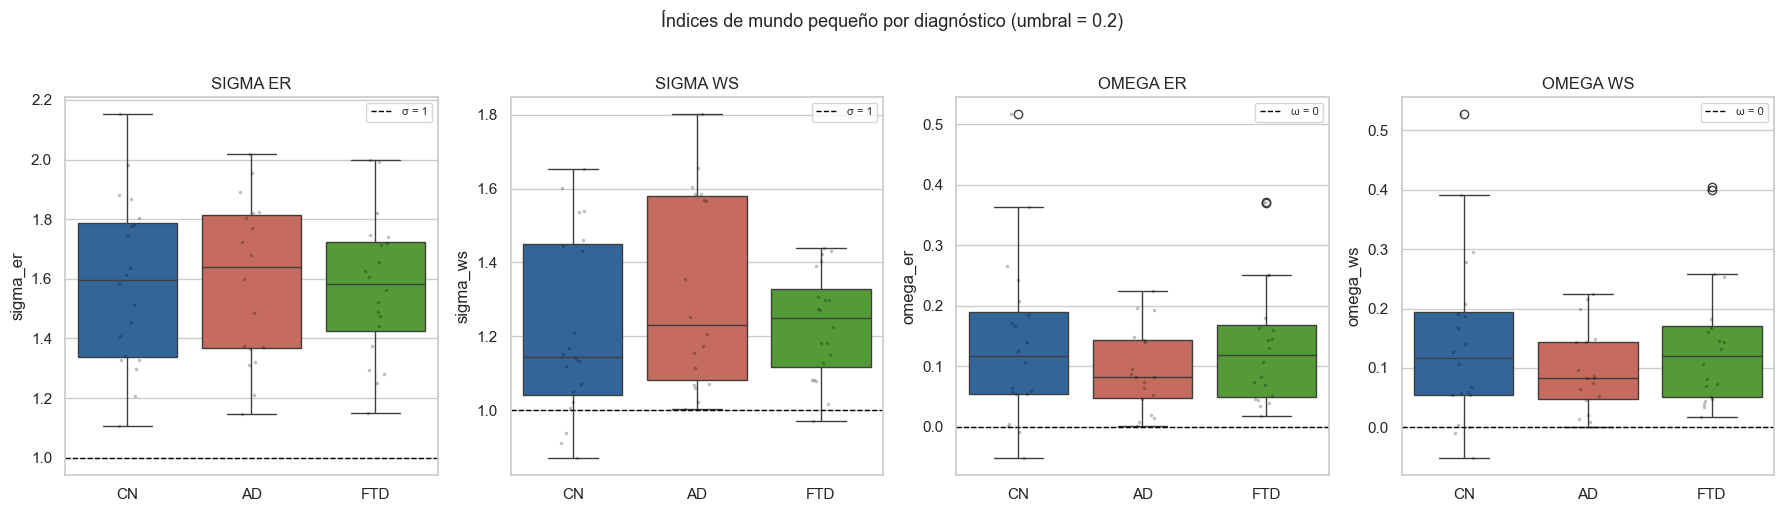

In [14]:
COLORS = {'CN': '#2166ac', 'AD': '#d6604d', 'FTD': '#4dac26'}

print(f'Índices SW (umbral = {THRESHOLD}):')
print(sw_df.groupby('diagnosis')[['sigma_er','sigma_ws','omega_er','omega_ws']].mean().round(3))

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, col, ref, ref_label in zip(
    axes,
    ['sigma_er', 'sigma_ws', 'omega_er', 'omega_ws'],
    [1.0, 1.0, 0.0, 0.0],
    ['σ = 1', 'σ = 1', 'ω = 0', 'ω = 0'],
):
    sub = sw_df[sw_df.diagnosis.isin(['CN','AD','FTD'])]
    sns.boxplot(data=sub, x='diagnosis', y=col, order=['CN','AD','FTD'],
                palette=COLORS, ax=ax)
    sns.stripplot(data=sub, x='diagnosis', y=col, order=['CN','AD','FTD'],
                  color='black', alpha=0.25, size=2.5, ax=ax)
    ax.axhline(ref, color='black', linestyle='--', linewidth=1, label=ref_label)
    ax.set_title(col.replace('_', ' ').upper())
    ax.set_xlabel('')
    ax.legend(fontsize=8)

plt.suptitle(f'Índices de mundo pequeño por diagnóstico (umbral = {THRESHOLD})',
             y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('figs/04_sw_by_diagnosis.png', dpi=150)
plt.show()

## 7. ¿Son las redes mundo pequeño? Cerebro vs. nulos

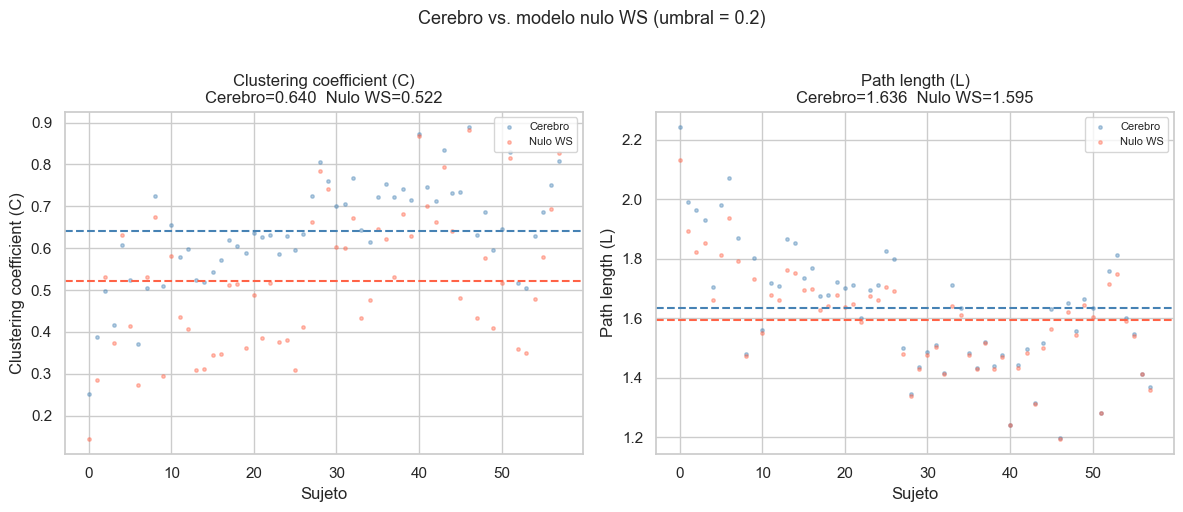

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (brain_m, null_m, null_name, ylabel) in zip(axes, [
    ('C', 'C_ws', 'WS', 'Clustering coefficient (C)'),
    ('L', 'L_ws', 'WS', 'Path length (L)'),
]):
    vals_brain = sw_df[brain_m]
    vals_null  = sw_df[null_m]
    ax.scatter(range(len(sw_df)), vals_brain, s=6, alpha=0.4, color='steelblue', label='Cerebro')
    ax.scatter(range(len(sw_df)), vals_null,  s=6, alpha=0.4, color='tomato',    label=f'Nulo {null_name}')
    ax.axhline(vals_brain.mean(), color='steelblue', linestyle='--', linewidth=1.5)
    ax.axhline(vals_null.mean(),  color='tomato',    linestyle='--', linewidth=1.5)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Sujeto')
    ax.set_title(f'{ylabel}\nCerebro={vals_brain.mean():.3f}  Nulo WS={vals_null.mean():.3f}')
    ax.legend(fontsize=8)

plt.suptitle(f'Cerebro vs. modelo nulo WS (umbral = {THRESHOLD})', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('figs/04_brain_vs_null.png', dpi=150)
plt.show()

## 8. Tests estadísticos entre diagnósticos

In [16]:
from itertools import combinations
from scipy.stats import mannwhitneyu

subset    = sw_df[sw_df.diagnosis.isin(['CN','AD','FTD'])]
diagnoses = ['CN','AD','FTD']
sw_metrics_list = ['sigma_er','sigma_ws','omega_er','omega_ws']

posthoc_rows = []
for metric in sw_metrics_list:
    groups = [subset.loc[subset.diagnosis==d, metric].dropna() for d in diagnoses]
    H, p_kw = stats.kruskal(*groups)
    print(f'{metric}: Kruskal-Wallis H={H:.2f}, p={p_kw:.4f}')

    pvals = []
    pairs_list = list(combinations(diagnoses, 2))
    for d1, d2 in pairs_list:
        g1 = subset.loc[subset.diagnosis==d1, metric].dropna()
        g2 = subset.loc[subset.diagnosis==d2, metric].dropna()
        _, p = mannwhitneyu(g1, g2, alternative='two-sided')
        pvals.append(p)

    _, pvals_fdr, _, _ = multipletests(pvals, method='fdr_bh')
    for (d1, d2), p_raw, p_fdr in zip(pairs_list, pvals, pvals_fdr):
        posthoc_rows.append({
            'metric': metric, 'group1': d1, 'group2': d2,
            'p_raw': round(p_raw, 5), 'p_fdr': round(p_fdr, 5),
            'significant': p_fdr < 0.05,
        })
    print()

posthoc_df = pd.DataFrame(posthoc_rows)
posthoc_df.to_csv('outputs/sw_metrics/posthoc_comparisons.csv', index=False)
print('Comparaciones significativas (FDR < 0.05):')
print(posthoc_df[posthoc_df['significant']].to_string(index=False))

sigma_er: Kruskal-Wallis H=0.14, p=0.9319

sigma_ws: Kruskal-Wallis H=1.50, p=0.4733

omega_er: Kruskal-Wallis H=0.93, p=0.6287

omega_ws: Kruskal-Wallis H=0.99, p=0.6110

Comparaciones significativas (FDR < 0.05):
Empty DataFrame
Columns: [metric, group1, group2, p_raw, p_fdr, significant]
Index: []


In [17]:
print(f'Archivos guardados (umbral = {THRESHOLD}):')
print('  outputs/sw_metrics/sw_metrics.csv          — C, L, σ, ω por sujeto')
print('  outputs/sw_metrics/posthoc_comparisons.csv — comparaciones post-hoc FDR')
print('  figs/04_sw_by_diagnosis.png')
print('  figs/04_brain_vs_null.png')
print()
print('Resumen σ_WS por diagnóstico:')
print(sw_df.groupby('diagnosis')['sigma_ws'].describe().round(3))
print()
print('Resumen ω_WS por diagnóstico:')
print(sw_df.groupby('diagnosis')['omega_ws'].describe().round(3))

Archivos guardados (umbral = 0.2):
  outputs/sw_metrics/sw_metrics.csv          — C, L, σ, ω por sujeto
  outputs/sw_metrics/posthoc_comparisons.csv — comparaciones post-hoc FDR
  figs/04_sw_by_diagnosis.png
  figs/04_brain_vs_null.png

Resumen σ_WS por diagnóstico:
           count   mean    std    min    25%    50%    75%    max
diagnosis                                                        
AD          18.0  1.325  0.263  1.004  1.082  1.230  1.581  1.801
CN          20.0  1.223  0.247  0.871  1.042  1.145  1.450  1.654
FTD         20.0  1.232  0.144  0.972  1.117  1.249  1.328  1.440

Resumen ω_WS por diagnóstico:
           count   mean    std    min    25%    50%    75%    max
diagnosis                                                        
AD          18.0  0.095  0.070  0.001  0.048  0.083  0.144  0.225
CN          20.0  0.143  0.144 -0.051  0.055  0.117  0.195  0.527
FTD         20.0  0.141  0.113  0.018  0.051  0.119  0.171  0.405
